# Forest Cover Type Classification With Deep Learning

The purpose of this project is to develop a `deep learning` model that is capable of predicting forest types from environmental and geographic features. The dataset contains measurements of key features such as `Elevation`, `Slope` and `Soil_Type` which will be used to classify each observation into one of 7 different classes. The dataset contains class labels that will be used to evaluate and test the effectiveness of the neural network. 

Several neural networks with differing hyper-parameters are created and evaluated to determine which hyper-parameters lead to the best performance. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [84]:
import sys
print(sys.executable)

/Volumes/George_Work/Learning/Programming/Data Science/IT_Career_Switch/Portfolio Projects/In Progress/Forest Cover Classification/dlsp-portfolio-starter-code/venv/bin/python


## Exploratory Data Analysis & Preprocessing

#### EDA

Before building any networks, the dataset was first explored to get an idea of its structure, identify any potential data quality issues such as null values and to get an idea of the distribution of the predictor variables.

The analysis focussed on:

    - Dataset dimensions and data types
    - missing values and duplicated entries
    - Class balance
    - Distributions of the predictor variables

In [85]:
df = pd.read_csv('cover_data.csv')


In [86]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,class
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [87]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())

(581012, 55)
<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-nul

As seen above, the dataset contains no missing or duplicated values, meaning that no cleaning or handling of missing data through methods such as imputing is necessary prior to building the models. The summary statistics also indicate that the predictor variables are a mixture of one-hot encoded categorical data and continuous variables that span very different ranges. This suggests that scaling will be needed prior to modelling to avoid the networks from having a disproportionate emphasis on features with a higher numerical scale. 

To address this, `StandardScaler()` will be used to fit and transform the training data, then the fitted scaler will also be used on the validation and testing data. Scaling the features so that they are on a similar scale will benefit the gradient descent used to update the weights during model training, resulting in faster training and potentially a better performance. 



Text(0, 0.5, 'Count')

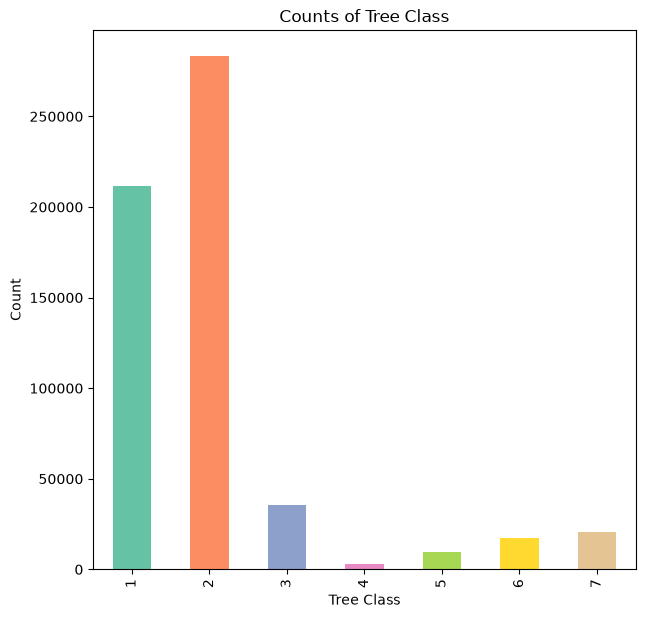

In [88]:
class_counts = df["class"].value_counts().sort_index()
plt.figure(figsize=(7, 7))
class_counts.plot(kind='bar', color = plt.cm.Set2(range(len(class_counts))))
plt.title("Counts of Tree Class")
plt.xlabel("Tree Class")
plt.ylabel("Count")

The target variable contains seven different classes of tree type with a high level of imbalance. Class `1` and `2` dominate the dataset with each having over 200,000 observations, while the rest of the classes are heavily underrepresented in comparison. 

This class imbalance might make it difficult for the neural networks to accurately classify the minority classes as they will naturally receive more data from the two classes that dominate the dataset. As a result, the accuracy of the model should be evaluated on a class by class basis by utilising a confusion matrix, ensuring that a high accuracy is not being driven from being biased towards the dominant classes. 

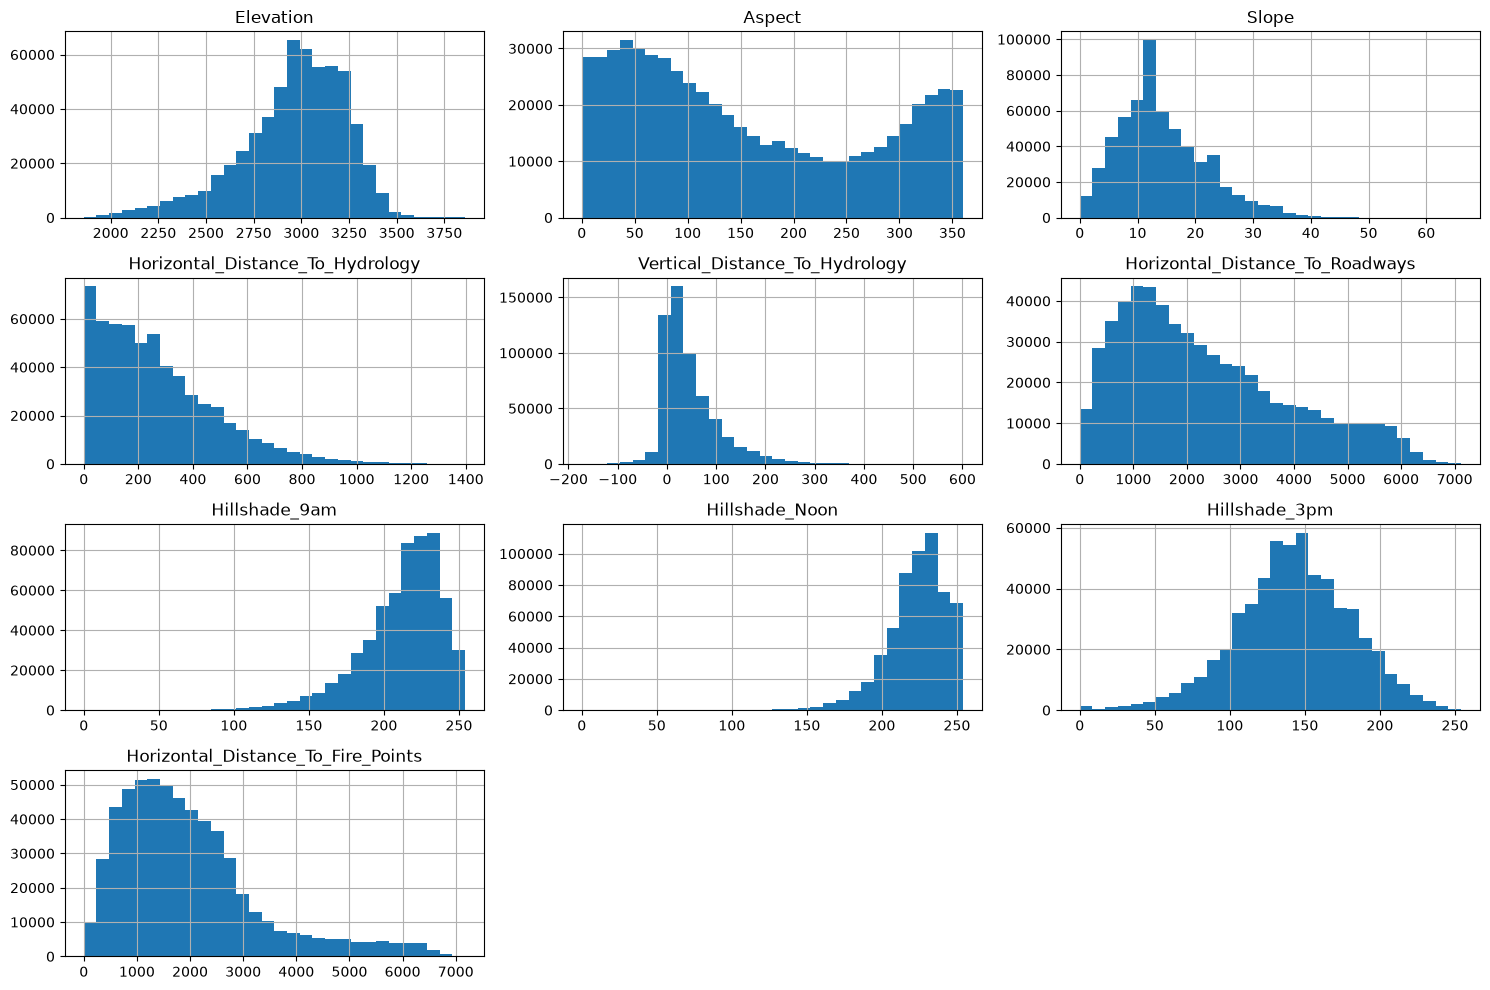

In [89]:
continuous_features = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

df[continuous_features].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

Histograms were created for the continuous features in the dataset to view their distribution and identify any potential problems prior to modelling. 

The features show a variety of distributions. `Elevation` is roughly normally distributed, with most observations happening at the middle of the range. Distance-based features such as `Distance_To_Hydrology` and `Distance_To_Roadways` show a right skew, with fewer observations at larger distances. 

No extreme anomalies were identified from the distributions, but it's worth noting once more that feature scaling will be needed as a consequence of the different scales that are recorded. 

In [90]:
for feature in continuous_features:
    print("\n", feature)
    
    counts, bins = np.histogram(df[feature], bins=30)
    
    for i in range(len(counts)):
        print(f"{bins[i]:.1f} - {bins[i+1]:.1f}: {counts[i]}")


 Elevation
1859.0 - 1925.6: 243
1925.6 - 1992.3: 885
1992.3 - 2058.9: 1864
2058.9 - 2125.5: 2994
2125.5 - 2192.2: 3521
2192.2 - 2258.8: 4139
2258.8 - 2325.4: 6229
2325.4 - 2392.1: 7481
2392.1 - 2458.7: 8398
2458.7 - 2525.3: 9733
2525.3 - 2592.0: 15533
2592.0 - 2658.6: 19472
2658.6 - 2725.2: 24601
2725.2 - 2791.9: 31173
2791.9 - 2858.5: 37160
2858.5 - 2925.1: 47895
2925.1 - 2991.8: 65289
2991.8 - 3058.4: 61973
3058.4 - 3125.0: 55255
3125.0 - 3191.7: 55887
3191.7 - 3258.3: 54002
3258.3 - 3324.9: 34549
3324.9 - 3391.6: 19398
3391.6 - 3458.2: 9222
3458.2 - 3524.8: 2225
3524.8 - 3591.5: 922
3591.5 - 3658.1: 390
3658.1 - 3724.7: 256
3724.7 - 3791.4: 154
3791.4 - 3858.0: 169

 Aspect
0.0 - 12.0: 28487
12.0 - 24.0: 28514
24.0 - 36.0: 29682
36.0 - 48.0: 31471
48.0 - 60.0: 30131
60.0 - 72.0: 28799
72.0 - 84.0: 28291
84.0 - 96.0: 26066
96.0 - 108.0: 23874
108.0 - 120.0: 22347
120.0 - 132.0: 20157
132.0 - 144.0: 18210
144.0 - 156.0: 16114
156.0 - 168.0: 14484
168.0 - 180.0: 12965
180.0 - 192.0: 1

#### Preprocessing

The predictor variables and the target classes were first separated before being split and scaled, with the variable `labels` containing the classes for each observation. The labels were then adjusted to start from 0 as opposed to 1 as TensorFlow's categorical function expects classes to start at zero. 

The dataset was then split into `training`, `validation` and `test` sets, with the training set consisting of 70% of the dataset. The remaining 30% was split evenly between validation and test data. 

The data was then scaled using `StandardScaler()`, with the scaler being fitted only on the training data and then applied to the validation and test sets. This prevents information from the validation and training sets from influencing the scaler, thus avoiding data leakage. 

In [91]:
features = df.iloc[:, :-1]
labels = df.iloc[:, -1]

# Make the classes start at 0 instead of 1
labels = labels-1


#split into training, evaluation and test data
X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.3, stratify=labels, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state = 42)


#scale the data

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

## Model Building, Training & Tuning

#### Baseline Model

The first model is a baseline model for which the subsequent models will be evaluated against. It contains a simple `Sequential()` network with 2 layers containing 64 and 32 neurons respectively. These two layers both use the `ReLU` activation function. The final output layer contains 7 neurons, representing the 7 available classes, and uses the `softmax` activation function to produce the probability of each observation belonging to each class. 

The model was then compiled using the `Adam` optimiser and `sparse_categorical_crossentropy` for the loss function. `Adam` was selected because it combines the benefits of adaptive learning rates with momentum, making it a strong default optimiser. `Sparse_categorical_crossentropy` was selected as the classes are integer-encoded as opposed to one-hot encoded and the model performance was monitored using the `accuracy` metric. 

Training was then performed for a maximum of 50 epochs, with `EarlyStopping` being used to reduce the risk of over-fitting. If the validation loss failed to improve for 5 consecutive epochs, the training of the model will be stopped and the best performing weights will be restored. 

After training, the model was tested on the unseen dataset, with accuracy and loss being recorded. Class predictions were also generated to produce a class report and confusion matrix for a more detailed evaluation of the neural network's performance. 

In [92]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(7, activation='softmax'))

model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=['accuracy'])
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=128, callbacks=[early_stopping])

Epoch 1/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 665us/step - accuracy: 0.7432 - loss: 0.6085 - val_accuracy: 0.7741 - val_loss: 0.5293
Epoch 2/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 621us/step - accuracy: 0.7831 - loss: 0.5040 - val_accuracy: 0.7953 - val_loss: 0.4902
Epoch 3/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 674us/step - accuracy: 0.8000 - loss: 0.4668 - val_accuracy: 0.8070 - val_loss: 0.4525
Epoch 4/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 587us/step - accuracy: 0.8109 - loss: 0.4432 - val_accuracy: 0.8169 - val_loss: 0.4341
Epoch 5/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 606us/step - accuracy: 0.8192 - loss: 0.4262 - val_accuracy: 0.8217 - val_loss: 0.4203
Epoch 6/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 633us/step - accuracy: 0.8259 - loss: 0.4132 - val_accuracy: 0.8246 - val_loss: 0.4127
Epoch 7/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 812us/step - accuracy: 0.8305 - loss: 0.4030 - val_accuracy: 0.8319 - val_loss: 0.4000
Epoch 8/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 817us/step - accuracy: 0.8339 -

In [94]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("test loss: {}".format(test_loss))
print("test accuracy: {}".format(test_accuracy))

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 338us/step - accuracy: 0.8711 - loss: 0.3141
test loss: 0.31412678956985474
test accuracy: 0.8710528612136841


In [95]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes)

   1/2724 ━━━━━━━━━━━━━━━━━━━━ 1:15 28ms/step

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 247us/step
[0 1 1 ... 0 1 1]


In [96]:
print(classification_report(y_test, predicted_classes))
cm = confusion_matrix(y_test, predicted_classes)

print(cm)

              precision    recall  f1-score   support

           0       0.86      0.88      0.87     31776
           1       0.89      0.89      0.89     42496
           2       0.87      0.84      0.86      5363
           3       0.77      0.74      0.75       412
           4       0.78      0.49      0.60      1424
           5       0.74      0.73      0.73      2605
           6       0.91      0.86      0.88      3076

    accuracy                           0.87     87152
   macro avg       0.83      0.77      0.80     87152
weighted avg       0.87      0.87      0.87     87152

[[27834  3696     0     0    18     7   221]
 [ 3964 38031   134     1   174   163    29]
 [    9   297  4520    71     4   462     0]
 [    0     0    66   304     0    42     0]
 [   97   592    37     0   698     0     0]
 [   13   249   425    20     1  1897     0]
 [  429    16     0     0     1     0  2630]]


#### Model2 – Increased Hidden Units

The second model investigates whether an increased  capacity of the neural network results in better model performance by increasing the two layers from 64 and 32 neurons to 128 and 64 respectively. 

Increasing the number of neurons allows the model to identify more complex patterns within the data by having more trainable parameters in the network. This increased capacity may improve model performance if our baseline network is under-fitting to the data, but is also be more susceptible to over-fitting and it does require more computational resources during training. 

All of the other parameters in the model were kept the same, allowing the impact of increasing the number of hidden units to be assessed in isolation. 

In [97]:
model2 = Sequential()
model2.add(Input(shape=(X_train.shape[1],)))
model2.add(Dense(128, activation='relu'))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(7, activation='softmax'))

model2.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=['accuracy'])

model2.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 128)            │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,751 (61.53 KB)

 Trainable params: 15,751 (61.53 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
early_stopping_2 = EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True)
history2 = model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=128, callbacks=[early_stopping_2])

Epoch 1/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 718us/step - accuracy: 0.7598 - loss: 0.5638 - val_accuracy: 0.7921 - val_loss: 0.4864
Epoch 2/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 682us/step - accuracy: 0.8059 - loss: 0.4531 - val_accuracy: 0.8166 - val_loss: 0.4284
Epoch 3/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 694us/step - accuracy: 0.8268 - loss: 0.4098 - val_accuracy: 0.8310 - val_loss: 0.4016
Epoch 4/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 686us/step - accuracy: 0.8401 - loss: 0.3824 - val_accuracy: 0.8327 - val_loss: 0.4008
Epoch 5/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 701us/step - accuracy: 0.8484 - loss: 0.3627 - val_accuracy: 0.8517 - val_loss: 0.3584
Epoch 6/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 693us/step - accuracy: 0.8552 - loss: 0.3478 - val_accuracy: 0.8580 - val_loss: 0.3445
Epoch 7/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 685us/step - accuracy: 0.8606 - loss: 0.3359 - val_accuracy: 0.8619 - val_loss: 0.3376
Epoch 8/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 714us/step - accuracy: 0.8652 -

In [99]:
test_loss2, test_accuracy2 = model2.evaluate(X_test, y_test)

   1/2724 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.8438 - loss: 0.2345

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 376us/step - accuracy: 0.9074 - loss: 0.2347


In [100]:
predictions2 = model2.predict(X_test)

predicted_classes2 = np.argmax(predictions2, axis=1)

print(predicted_classes2)

print(classification_report(y_test, predicted_classes2))
cm = confusion_matrix(y_test, predicted_classes2)

print(cm)


2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 244us/step
[0 1 1 ... 0 1 1]
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     31776
           1       0.90      0.95      0.92     42496
           2       0.89      0.92      0.91      5363
           3       0.86      0.74      0.79       412
           4       0.76      0.75      0.76      1424
           5       0.87      0.78      0.82      2605
           6       0.94      0.91      0.92      3076

    accuracy                           0.91     87152
   macro avg       0.88      0.85      0.86     87152
weighted avg       0.91      0.91      0.91     87152

[[27708  3853     3     0    45     7   160]
 [ 1761 40232   131     0   277    71    24]
 [    0   180  4940    38     7   198     0]
 [    0     1    72   304     0    35     0]
 [   39   282    29     0  1069     5     0]
 [    3   199   352    13     2  2036     0]
 [  223    60     0     0     1     0  2792]]


#### Model3 – Adding Dropout

The third model investigates whether adding `dropout regularisation` improves the model's predictive accuracy. The same model architecture of `model2` was retained, but after each hidden layer there is a dropout of 0.3, meaning that 30% of the neurons are deactivated at random on every epoch of the training. This prevents the network from becoming overly reliant on specific neurons, encouraging it to be more generalised to unseen data and reducing the risk of over-fitting. 

All of the other parameters are again kept the same, allowing the introduction of dropout regularisation to be assessed in isolation. 

In [101]:
model3 = Sequential()
model3.add(Input(shape=(X_train.shape[1],)))
model3.add(Dense(128, activation='relu'))
model3.add(Dropout(0.3))
model3.add(Dense(64, activation='relu'))
model3.add(Dropout(0.3))
model3.add(Dense(7, activation='softmax'))

model3.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model3.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 128)            │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,751 (61.53 KB)

 Trainable params: 15,751 (61.53 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
early_stopping_3 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history3 = model3.fit(X_train, y_train, batch_size=128, epochs=50, validation_data = (X_val, y_val), callbacks=[early_stopping_3])

Epoch 1/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 861us/step - accuracy: 0.7177 - loss: 0.6671 - val_accuracy: 0.7647 - val_loss: 0.5509
Epoch 2/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 827us/step - accuracy: 0.7537 - loss: 0.5687 - val_accuracy: 0.7826 - val_loss: 0.5074
Epoch 3/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 817us/step - accuracy: 0.7666 - loss: 0.5381 - val_accuracy: 0.7951 - val_loss: 0.4777
Epoch 4/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 810us/step - accuracy: 0.7750 - loss: 0.5177 - val_accuracy: 0.8008 - val_loss: 0.4586
Epoch 5/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - accuracy: 0.7807 - loss: 0.5051 - val_accuracy: 0.8116 - val_loss: 0.4449
Epoch 6/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 820us/step - accuracy: 0.7843 - loss: 0.4965 - val_accuracy: 0.8180 - val_loss: 0.4312
Epoch 7/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 815us/step - accuracy: 0.7892 - loss: 0.4895 - val_accuracy: 0.8217 - val_loss: 0.4242
Epoch 8/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 808us/step - accuracy: 0.7922 -

In [103]:
test_loss3, test_accuracy3 = model3.evaluate(X_test, y_test)

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 368us/step - accuracy: 0.8534 - loss: 0.3521


In [104]:
predictions3 = model3.predict(X_test)

predicted_classes3 = np.argmax(predictions3, axis=1)

print(predicted_classes3)

print(classification_report(y_test, predicted_classes3))
cm = confusion_matrix(y_test, predicted_classes3)

print(cm)

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 238us/step
[0 2 1 ... 0 1 1]
              precision    recall  f1-score   support

           0       0.88      0.82      0.85     31776
           1       0.85      0.92      0.88     42496
           2       0.79      0.89      0.84      5363
           3       0.88      0.49      0.63       412
           4       0.83      0.30      0.45      1424
           5       0.75      0.57      0.65      2605
           6       0.92      0.82      0.86      3076

    accuracy                           0.85     87152
   macro avg       0.84      0.69      0.74     87152
weighted avg       0.85      0.85      0.85     87152

[[26012  5535     9     0     3     7   210]
 [ 3058 38967   208     0    84   161    18]
 [    0   299  4761    26     1   276     0]
 [    0     0   169   203     0    40     0]
 [   74   881    35     0   433     1     0]
 [    4   300   809     3     0  1489     0]
 [  540    29     0     0     0     0  2507]]


#### Model4 – Increasing Learning Rate

The fourth model investigates the effect of increasing the `learning rate` that is used by the adam optimiser. The architecture of the neural network is kept the same as in model2, but the learning rate was increased from the default of `0.001` to `0.01`, ie 10 times the amount. a larger learning rate allows the model to update its weights with larger steps during gradient descent, which may allow the model to converge faster. However, if the learning rate is too high the model may might become unstable as a result of the larger steps, potentially reducing its performance. Again, early stopping was used to stop the model if 5 consecutive epochs had a decreased performance. 

In [105]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

model4 = Sequential()
model4.add(Input(shape=(X_train.shape[1],)))
model4.add(Dense(128, activation='relu'))
model4.add(Dense(64, activation='relu'))
model4.add(Dense(7, activation='softmax'))

model4.compile(optimizer = optimizer, loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
model4.summary()


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 128)            │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,751 (61.53 KB)

 Trainable params: 15,751 (61.53 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
early_stopping_4 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history4 = model4.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=128, callbacks=[early_stopping_4])

Epoch 1/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 712us/step - accuracy: 0.7657 - loss: 0.5447 - val_accuracy: 0.7926 - val_loss: 0.4903
Epoch 2/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 678us/step - accuracy: 0.8076 - loss: 0.4590 - val_accuracy: 0.8128 - val_loss: 0.4551
Epoch 3/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 675us/step - accuracy: 0.8243 - loss: 0.4254 - val_accuracy: 0.8262 - val_loss: 0.4252
Epoch 4/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 847us/step - accuracy: 0.8332 - loss: 0.4064 - val_accuracy: 0.8327 - val_loss: 0.4081
Epoch 5/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 699us/step - accuracy: 0.8406 - loss: 0.3913 - val_accuracy: 0.8425 - val_loss: 0.3932
Epoch 6/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8457 - loss: 0.3804 - val_accuracy: 0.8422 - val_loss: 0.3891
Epoch 7/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 882us/step - accuracy: 0.8500 - loss: 0.3719 - val_accuracy: 0.8459 - val_loss: 0.3827
Epoch 8/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8529 - los

In [107]:
test_loss4, test_accuracy4 = model4.evaluate(X_test, y_test)

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 362us/step - accuracy: 0.8755 - loss: 0.3244


In [108]:
predictions4 = model4.predict(X_test)

predicted_classes4 = np.argmax(predictions4, axis=1)

print(predicted_classes4)

print(classification_report(y_test, predicted_classes4))
cm = confusion_matrix(y_test, predicted_classes4)

print(cm)

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 259us/step
[0 2 1 ... 0 1 1]
              precision    recall  f1-score   support

           0       0.92      0.83      0.87     31776
           1       0.87      0.94      0.90     42496
           2       0.85      0.83      0.84      5363
           3       0.79      0.59      0.68       412
           4       0.66      0.65      0.65      1424
           5       0.71      0.67      0.69      2605
           6       0.88      0.87      0.88      3076

    accuracy                           0.88     87152
   macro avg       0.81      0.77      0.79     87152
weighted avg       0.88      0.88      0.87     87152

[[26530  4860     0     0    39     4   343]
 [ 1985 39735   154     2   438   156    26]
 [    0   378  4429    41     3   512     0]
 [    0    27   107   243     0    35     0]
 [   36   430    27     0   925     6     0]
 [    2   327   501    20     0  1755     0]
 [  339    55     0     0     1     0  2681]]


#### Model5 – Decreasing Learning Rate

The 5th model investigates the effects of decreasing the learning rate, as opposed to increasing it as in model4. Again, besides the learning rate the architecture of the model is kept the same as model2. Smaller steps during gradient descent may allow the model to converge to a better solution. As with the previous models, early stopping was used to prevent overfitting, and performance was evaluated using the test accuracy, classification report, and confusion matrix.

In [109]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model5 = Sequential()
model5.add(Input(shape=(X_train.shape[1],)))
model5.add(Dense(128, activation='relu'))
model5.add(Dense(64, activation='relu'))
model5.add(Dense(7, activation='softmax'))

model5.compile(optimizer = optimizer, loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
model5.summary()


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 128)            │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,751 (61.53 KB)

 Trainable params: 15,751 (61.53 KB)

 Non-trainable params: 0 (0.00 B)

In [110]:
early_stopping_5 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history5 = model5.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=128, callbacks=[early_stopping_5])

Epoch 1/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 734us/step - accuracy: 0.7449 - loss: 0.6025 - val_accuracy: 0.7767 - val_loss: 0.5250
Epoch 2/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 693us/step - accuracy: 0.7871 - loss: 0.4956 - val_accuracy: 0.7967 - val_loss: 0.4786
Epoch 3/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 711us/step - accuracy: 0.8082 - loss: 0.4537 - val_accuracy: 0.8174 - val_loss: 0.4398
Epoch 4/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 696us/step - accuracy: 0.8217 - loss: 0.4252 - val_accuracy: 0.8215 - val_loss: 0.4216
Epoch 5/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 676us/step - accuracy: 0.8316 - loss: 0.4038 - val_accuracy: 0.8332 - val_loss: 0.4010
Epoch 6/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 674us/step - accuracy: 0.8392 - loss: 0.3872 - val_accuracy: 0.8365 - val_loss: 0.3905
Epoch 7/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 699us/step - accuracy: 0.8451 - loss: 0.3740 - val_accuracy: 0.8412 - val_loss: 0.3847
Epoch 8/50
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 2s 684us/step - accuracy: 0.8500 -

In [111]:
test_loss5, test_accuracy5 = model5.evaluate(X_test, y_test)

   1/2724 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9062 - loss: 0.1520

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 387us/step - accuracy: 0.8973 - loss: 0.2584


In [112]:
predictions5 = model5.predict(X_test)

predicted_classes5 = np.argmax(predictions5, axis=1)

print(predicted_classes5)

print(classification_report(y_test, predicted_classes5))
cm = confusion_matrix(y_test, predicted_classes5)

print(cm)

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 249us/step
[0 2 1 ... 0 1 1]
              precision    recall  f1-score   support

           0       0.91      0.87      0.89     31776
           1       0.89      0.94      0.91     42496
           2       0.88      0.89      0.89      5363
           3       0.87      0.73      0.79       412
           4       0.80      0.67      0.73      1424
           5       0.84      0.73      0.78      2605
           6       0.95      0.87      0.91      3076

    accuracy                           0.90     87152
   macro avg       0.88      0.82      0.84     87152
weighted avg       0.90      0.90      0.90     87152

[[27723  3903     1     0    29     3   117]
 [ 2213 39840   156     0   195    74    18]
 [    4   259  4798    34    13   255     0]
 [    0     0    73   299     0    40     0]
 [   42   398    26     0   958     0     0]
 [    2   274   403    12     2  1912     0]
 [  360    45     0     0     1     0  2670]]


## Model Evaluation

After training the 5 neural networks, the models were then compared to evaluate their performance based on `Accuracy` and `Loss`. However, due to the class imbalance mentioned in the exploratory analysis, accuracy alone may not fully represent how well each model classifies each coverage type. This is due to the potential of the models being biased towards classifying the coverage types with a larger number of observations. Therefore, additional methods of analysis such as `confusion matrices` and `f1 score` will be used to investigate behaviour across different classes. 

The aim of the evaluation is to identify the best performing model and assess whether its performance is consistent across all classes. 

The table below shows the performance of each model on the test dataset. `Accuracy` and `Loss` show the predictive performance of each network and `Epochs` shows how long each model was trained for before `Early Stopping` was triggered. 

The table is sorted by `Accuracy` to show which neural network achieved the best predictive performance.

The results show that the models performed within a relatively narrow range overall, although the choice of hyperparameters had a noticeable impact on performance. Increasing the number of hidden units resulted in better performance compared to the `baseline` model, suggesting that the additional model capacity helped capture more complex patterns in the observations. It’s also worth noting that `model5`, which used the lower learning rate, achieved the second-highest accuracy and a relatively low loss compared to the other models. `model4` trained for `34` epochs before Early Stopping was triggered, while `model5` trained for `49` epochs before stopping.

In [113]:
results = pd.DataFrame({"Model": ["Baseline", "Increased Neurons", "with Dropout", "Higher Learning Rate", "Lower Learning Rate"],
                        "Accuracy": [test_accuracy, test_accuracy2, test_accuracy3, test_accuracy4, test_accuracy5],
                        "Loss": [test_loss, test_loss2, test_loss3, test_loss4, test_loss5],
                        "Epochs": [len(history.history["loss"]), len(history2.history["loss"]), len(history3.history["loss"]), len(history4.history["loss"]), len(history5.history["loss"])]})

results = results.sort_values("Accuracy", ascending=False)
results = results.round(4)
results


,Model,Accuracy,Loss,Epochs
1,Increased Neurons,0.9074,0.2347,43
4,Lower Learning Rate,0.8973,0.2584,49
3,Higher Learning Rate,0.8755,0.3244,34
0,Baseline,0.8711,0.3141,50
2,with Dropout,0.8534,0.3521,42


Below is a visual representation of the accuracy achieved by each of the neural networks, sorted by performance. The models performed within a relatively narrow range, although the differences show that the choice of hyperparameters had a noticeable impact on performance. In particular, the `Increased Neurons` model achieved the highest accuracy, while the Higher Learning Rate and with Dropout models performed less well.

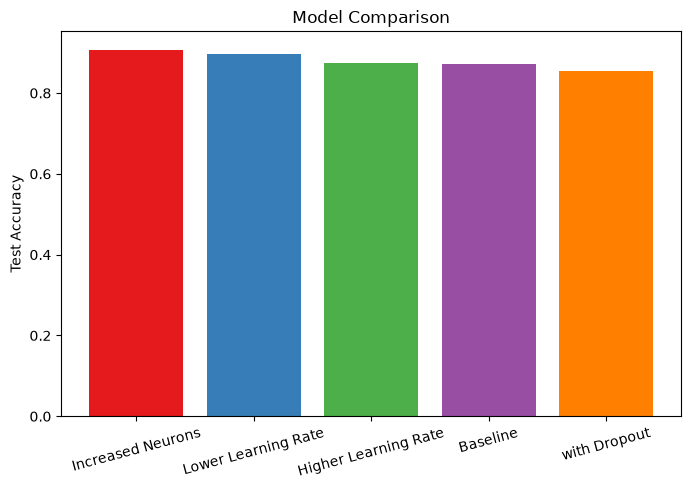

In [114]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"], color=plt.cm.Set1(range(len(results["Model"]))))
plt.ylabel("Test Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=15)
plt.show()

Validation accuracy was plotted against epochs to compare how quickly each model learned and how well they performed during training. Unlike the accuracy score from using the test data, which gives just a single accuracy score, the validation curve shows how each model generalises to unseen observations during the training process. 

`Model2`, which is referred to as `More Units`, shows the strongest network performance with approximately ~91% accuracy and a steady improvement across epochs. This suggests that increasing the amount of hidden units in the neural network allows the model to learn more complex patterns within the data, further backed up by the baseline model having a similar curve but a lower final score of ~87%. \
`Model3`, referred to as `Dropout` is below the `baseline` and the worst performing model, suggesting that the deactivation of neurons resulted in less patterns being learned by the neural network. \
`Model4`, referred to as `High LR` showed a faster learning rate at the start but became more unstable as the number of epochs increased, likely as a result of larger weight updates causing instability. \
`Model5`, referred to as `Low LR`, showed steady improvement but did not outperform `model2`. It trained for `49` of the `50` available epochs before Early Stopping was triggered, indicating that validation performance continued to improve for much of the training process.

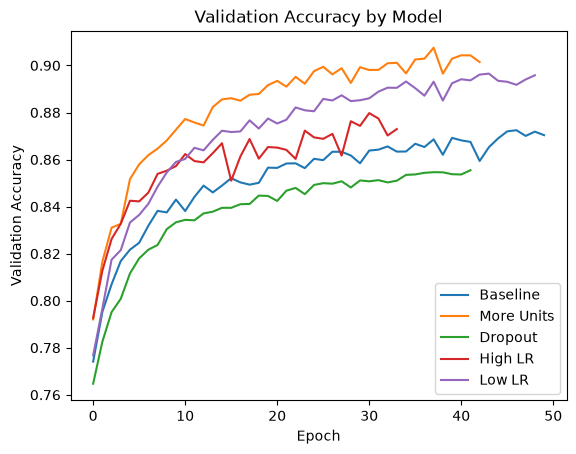

In [115]:
plt.plot(history.history['val_accuracy'], label='Baseline')
plt.plot(history2.history['val_accuracy'], label='More Units')
plt.plot(history3.history['val_accuracy'], label='Dropout')
plt.plot(history4.history['val_accuracy'], label='High LR')
plt.plot(history5.history['val_accuracy'], label='Low LR')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy by Model")
plt.legend()
plt.show()

The `Loss` of each model was also plotted across epochs to compare how effectively each model learned during training. Unlike `accuracy`, which only records the percentage of correct predictions, `loss` records the confidence of the model's predictions and is the value that is minimised during training. 

The results closely follow the trends observed in validation accuracy. `Model2` achieved the lowest validation loss, suggesting that increasing the number of hidden units improved the network's ability to learn patterns from the data. `Model3` had the highest validation loss, indicating that dropout reduced the model's learning capacity. `Model4` showed greater fluctuations due to the higher learning rate, while `Model5` demonstrated steady improvement with a slower learning rate.

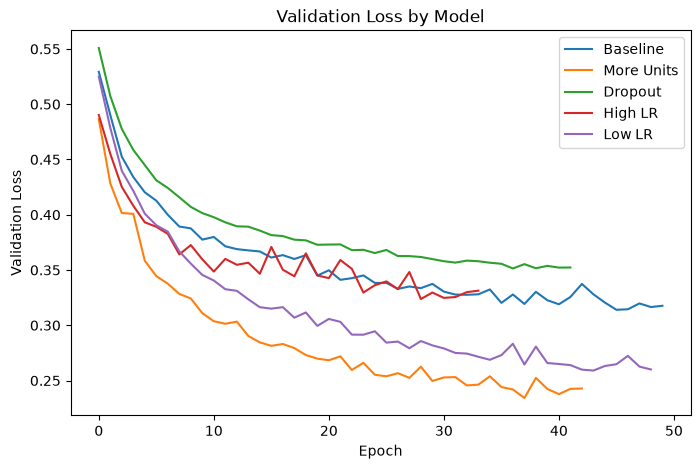

In [116]:
plt.figure(figsize=(8,5))

plt.plot(history.history['val_loss'], label='Baseline')
plt.plot(history2.history['val_loss'], label='More Units')
plt.plot(history3.history['val_loss'], label='Dropout')
plt.plot(history4.history['val_loss'], label='High LR')
plt.plot(history5.history['val_loss'], label='Low LR')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss by Model")
plt.legend()

plt.show()

The below confusion matrix was used to evaluate the effectiveness of `model2` across each individual forest cover class. Unlike overall accuracy, the confusion matrix shows a granularised view of the correct and incorrect predictions for each class. \
The correct predictions fall across the diagonal and in the below model they are the vast majority, indicating that the model has been effective at identifying every type of forest coverage. Ths strongest performance is seen in the majority classes, which makes sense given that the neural network would have seen more observations of those classes.  \
It's worth noting that the largest sources of misclassification happen between `class1` and `class2`, suggesting that these forest cover types share some similar characteristics in the predictor variables. 

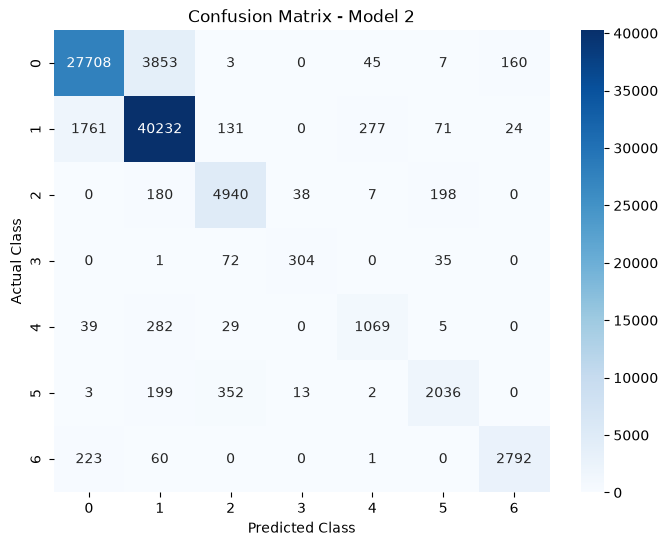

[[27708  3853     3     0    45     7   160]
 [ 1761 40232   131     0   277    71    24]
 [    0   180  4940    38     7   198     0]
 [    0     1    72   304     0    35     0]
 [   39   282    29     0  1069     5     0]
 [    3   199   352    13     2  2036     0]
 [  223    60     0     0     1     0  2792]]


In [117]:
cm = confusion_matrix(y_test, predicted_classes2)


plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Model 2")
plt.show()
print(cm)

## Final Model

In [118]:
model6 = Sequential()
model6.add(Input(shape=(X_train.shape[1],)))
model6.add(Dense(256, activation='relu'))
model6.add(Dense(128, activation='relu'))
model6.add(Dense(7, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model6.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model6.summary()



Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 256)            │        14,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,879 (187.03 KB)

 Trainable params: 47,879 (187.03 KB)

 Non-trainable params: 0 (0.00 B)

In [119]:
early_stopping_6 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
history6 = model6.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size = 128, callbacks=[early_stopping_6])

Epoch 1/100
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7587 - loss: 0.5671 - val_accuracy: 0.7872 - val_loss: 0.4987
Epoch 2/100
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8071 - loss: 0.4539 - val_accuracy: 0.8151 - val_loss: 0.4384
Epoch 3/100
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8305 - loss: 0.4056 - val_accuracy: 0.8400 - val_loss: 0.3880
Epoch 4/100
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8452 - loss: 0.3740 - val_accuracy: 0.8506 - val_loss: 0.3625
Epoch 5/100
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8558 - loss: 0.3503 - val_accuracy: 0.8591 - val_loss: 0.3436
Epoch 6/100
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8634 - loss: 0.3321 - val_accuracy: 0.8655 - val_loss: 0.3304
Epoch 7/100
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8705 - loss: 0.3171 - val_accuracy: 0.8720 - val_loss: 0.3153
Epoch 8/100
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8755 - loss: 0

In [120]:
test_loss6, test_accuracy6 = model6.evaluate(X_test, y_test)
predictions6 = model6.predict(X_test)

predicted_classes6 = np.argmax(predictions6, axis=1)

print(predicted_classes6)

print(classification_report(y_test, predicted_classes6))
cm6 = confusion_matrix(y_test, predicted_classes6)

print(cm6)

   1/2724 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.9062 - loss: 0.1081

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 389us/step - accuracy: 0.9309 - loss: 0.1817
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 1s 272us/step
[0 1 1 ... 0 1 1]
              precision    recall  f1-score   support

           0       0.93      0.92      0.93     31776
           1       0.93      0.95      0.94     42496
           2       0.95      0.90      0.93      5363
           3       0.88      0.78      0.83       412
           4       0.87      0.76      0.81      1424
           5       0.85      0.88      0.87      2605
           6       0.97      0.92      0.94      3076

    accuracy                           0.93     87152
   macro avg       0.91      0.87      0.89     87152
weighted avg       0.93      0.93      0.93     87152

[[29316  2373     0     0    16     7    64]
 [ 1818 40444    40     0   118    62    14]
 [    2   180  4842    32    19   288     0]
 [    0     0    46   322     0    44     0]
 [   23   304     5     0  1084     8     0]
 [    1   136   153    11     3  230

#### Evaluating the Final Model

The `validation accuracy` and `loss` of the final model was compared against the best performing model (`model2`) from the initial hyperparameter experiments. `Model2` increased the neurons from  `64 → 32` to `128 → 64`, and for the final model I took this idea further by increasing the neurons to `256 → 128`. The final model also adopted the decreased learning-rate from `model5` (`0.0005`). I chose to adopt this learning rate for the final model as model5 was the second-best performing initial model and trained for 49 of the 50 available epochs before Early Stopping was triggered. \
To test this the final model increased the number of epochs from `50` to `100`, allowing the larger network and smaller learning rate more time to converge. 

\
\
The below training curves indicate that the final model improved upon `model2` for both `accuracy` and `loss`.The below training curves indicate that the final model improved upon model2 for both accuracy and loss. The final model achieved 93.09% accuracy compared to 90.74% for model2. Additionally, the final model continued to improve beyond where model2 had plateaued, supporting the hypothesis that a smaller learning rate allows for more gradual optimisation. 
The loss curves follow a similar pattern, with the final model consistently having a lower loss than model2. This indicates that the final model achieved better predictive performance under the cross-entropy loss objective.

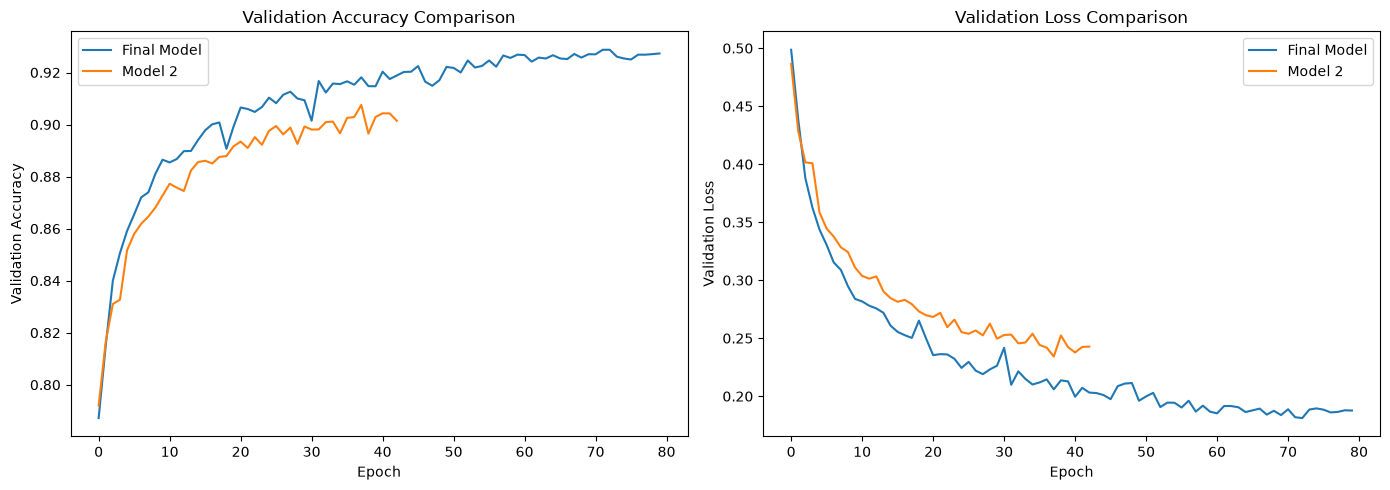

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation Accuracy
axes[0].plot(history6.history["val_accuracy"], label="Final Model")
axes[0].plot(history2.history["val_accuracy"], label="Model 2")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("Validation Accuracy Comparison")
axes[0].legend()

# Validation Loss
axes[1].plot(history6.history["val_loss"], label="Final Model")
axes[1].plot(history2.history["val_loss"], label="Model 2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].set_title("Validation Loss Comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

In [122]:
# print("model2 loss")
# print(history2.history['loss'])
# print("model6 loss")
# print(history6.history['loss'])
# print("model2 accuracy")
# print(history2.history['accuracy'])
# print("model6 accuracy")
# print(history6.history['accuracy'])

The confusion matrices below compares the classification performance of the `final model` against `model2`. \
The final model shows improvements across the majority of classes, with the strongest gains being seen in the dominant classes. For example, correct predictions of class `class 2` (1 in the confusion matrix) increased to `40444` from `40232`, whereas incorrect predictions of the same class decreased. The same trend is consistent with `class 1` (0 in the confusion matrix) indicating that the final neural network is better able to distinguish between these two commonly occurring forest cover types.'
The main sources of confusion remain similar between both models. The largest errors occur between **Classes 1 and 2**, and between **Classes 3 and 6**, suggesting that these forest cover types share similar characteristics within the predictor variables. However, the final model generally reduces these misclassifications, indicating that the increased network capacity helped the model identify more complex patterns.

Overall, the final model demonstrates improved classification performance compared to `model2`, with higher numbers of correct predictions across all major classes and fewer errors between commonly confused categories.

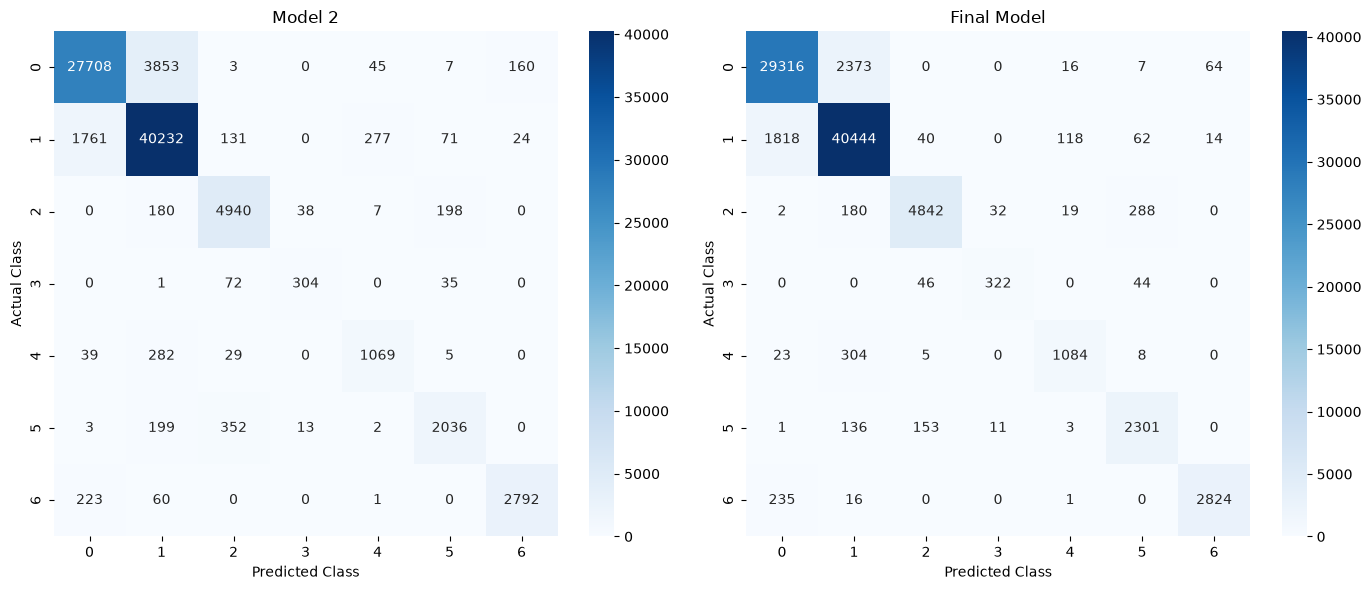

model2 cm
[[27708  3853     3     0    45     7   160]
 [ 1761 40232   131     0   277    71    24]
 [    0   180  4940    38     7   198     0]
 [    0     1    72   304     0    35     0]
 [   39   282    29     0  1069     5     0]
 [    3   199   352    13     2  2036     0]
 [  223    60     0     0     1     0  2792]]
model6 cm
[[29316  2373     0     0    16     7    64]
 [ 1818 40444    40     0   118    62    14]
 [    2   180  4842    32    19   288     0]
 [    0     0    46   322     0    44     0]
 [   23   304     5     0  1084     8     0]
 [    1   136   153    11     3  2301     0]
 [  235    16     0     0     1     0  2824]]


In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Model 2
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Model 2")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")
# Final Model
sns.heatmap(cm6, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Final Model")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("Actual Class")
plt.tight_layout()
plt.show()
print("model2 cm")
print(cm)
print("model6 cm")
print(cm6)

## Conclusion

In this project we developed a deep learning classification model capable of predicting forest cover types from continuous and categorical variables. After preprocessing the data and developing several different neural network architectures, increasing the number of hidden units and reducing the learning rate was found to have the biggest positive effect on the performance of the network. \
The `final model` expanded upon the best-performing network (`model2`) by increasing its hidden units to `256 → 128`, while also adopting the learning rate used in `model5` (`0.0005`) 
This resulted in the network's accuracy improving from roughly `~91%` in `model2` to `~93%` in the `final model`, demonstrating that the increased capacity of the final network and its slower learning rate allowed the `final model` to find more complex relationships within the predictor variables. 

The confusion matrix showed that the final model classified tree coverage type more accurately, displaying a reduction in errors between commonly confused forest types. However, some errors still remained, in particular between classes 1 and 2, suggesting that the cover types have some overlapping features that can cause misclassification. With that said however, the final network still showed a strong performance, demonstrating that deep learning networks are effective at classifying forest cover types from environmental and geographic measurements. 

#### Limitations 

Although the final model did achieve a strong classification performance, there are some limitations that should be considered.\
Firstly, the dataset contains a substantial class imbalance, with class 1 and 2 having the most observations by a large margin. While stratification was used to ensure the split datasets had similar class distributions, the model may still be biased towards the classes with more observations. Future variations of the model could perhaps use weighting or oversampling to adjust for the class imbalance. Additionally, while the `final model` achieved a high level of accuracy, its results are less interpretable than some ML techniques such as `decision trees`, making it more difficult to understand which variables contribute more towards classification. 



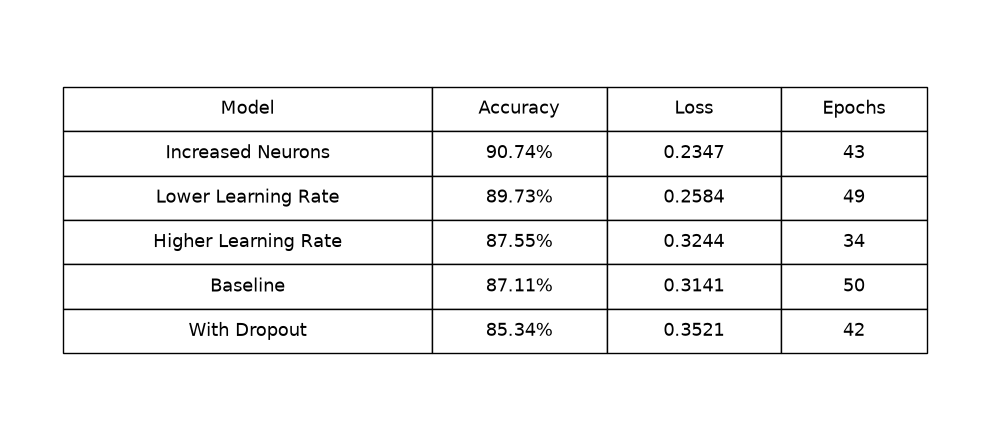

In [125]:
results_table = [

    ["Increased Neurons", "90.74%", "0.2347", "43"],

    ["Lower Learning Rate", "89.73%", "0.2584", "49"],

    ["Higher Learning Rate", "87.55%", "0.3244", "34"],

    ["Baseline", "87.11%", "0.3141", "50"],

    ["With Dropout", "85.34%", "0.3521", "42"]

]

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.axis("off")

table = ax.table(

    cellText=results_table,

    colLabels=["Model", "Accuracy", "Loss", "Epochs"],

    cellLoc="center",

    loc="center",

    colWidths=[0.38, 0.18, 0.18, 0.15]

)

table.auto_set_font_size(False)

table.set_fontsize(13)

table.scale(1, 2.2)

plt.tight_layout()

plt.savefig("model_results_table.png", dpi=300, bbox_inches="tight")

plt.show()


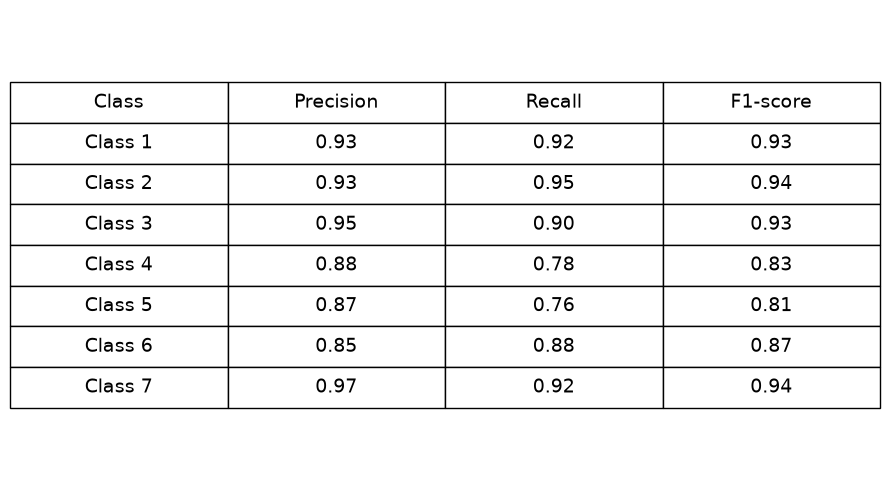

In [4]:
class_results = [

    ["Class 1", "0.93", "0.92", "0.93"],

    ["Class 2", "0.93", "0.95", "0.94"],

    ["Class 3", "0.95", "0.90", "0.93"],

    ["Class 4", "0.88", "0.78", "0.83"],

    ["Class 5", "0.87", "0.76", "0.81"],

    ["Class 6", "0.85", "0.88", "0.87"],

    ["Class 7", "0.97", "0.92", "0.94"]

]

fig, ax = plt.subplots(figsize=(9, 5))

ax.axis("off")

table = ax.table(

    cellText=class_results,

    colLabels=["Class", "Precision", "Recall", "F1-score"],

    cellLoc="center",

    loc="center",

    colWidths=[0.25, 0.25, 0.25, 0.25]

)

table.auto_set_font_size(False)

table.set_fontsize(14)

table.scale(1, 2)

plt.tight_layout()

plt.savefig("final_model_class_performance.png", dpi=300, bbox_inches="tight")

plt.show()